In [17]:
import pandas as pd

In [18]:
happiness = pd.read_csv("../data/happiness.csv")
income = pd.read_csv("../data/income.csv")
house = pd.read_csv("../data/house_price.csv")

happiness.head()

,city,happiness
0,Beijing,7.2
1,Shanghai,7.0
2,Guangzhou,6.8
3,Shenzhen,7.1
4,Hangzhou,7.3


In [19]:
df = happiness.merge(income, on="city").merge(house, on="city")
df

,city,happiness,income,house_price
0,Beijing,7.2,18000,65000
1,Shanghai,7.0,17500,60000
2,Guangzhou,6.8,14000,35000
3,Shenzhen,7.1,19000,70000
4,Hangzhou,7.3,16000,38000
5,Nanjing,6.9,13000,28000
6,Chengdu,7.4,11000,18000
7,Wuhan,6.7,10000,15000
8,Xi'an,6.8,9500,14000
9,Chongqing,7.0,10500,16000


In [20]:
df["value_index"] = df["income"] / df["house_price"]
df

,city,happiness,income,house_price,value_index
0,Beijing,7.2,18000,65000,0.276923
1,Shanghai,7.0,17500,60000,0.291667
2,Guangzhou,6.8,14000,35000,0.400000
3,Shenzhen,7.1,19000,70000,0.271429
4,Hangzhou,7.3,16000,38000,0.421053
5,Nanjing,6.9,13000,28000,0.464286
6,Chengdu,7.4,11000,18000,0.611111
7,Wuhan,6.7,10000,15000,0.666667
8,Xi'an,6.8,9500,14000,0.678571
9,Chongqing,7.0,10500,16000,0.656250


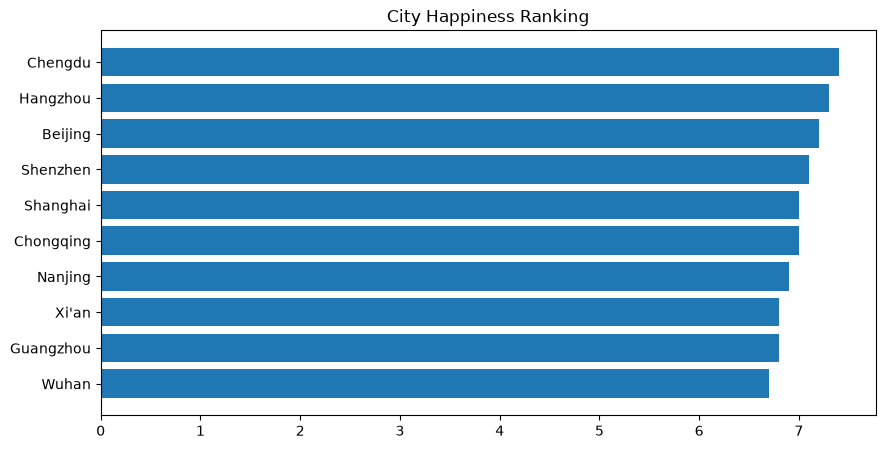

In [21]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values("happiness")

plt.figure(figsize=(10,5))
plt.barh(df_sorted["city"], df_sorted["happiness"])
plt.title("City Happiness Ranking")
plt.show()

In [22]:
df["value_index"] = df["income"] / df["house_price"]
df

,city,happiness,income,house_price,value_index
0,Beijing,7.2,18000,65000,0.276923
1,Shanghai,7.0,17500,60000,0.291667
2,Guangzhou,6.8,14000,35000,0.400000
3,Shenzhen,7.1,19000,70000,0.271429
4,Hangzhou,7.3,16000,38000,0.421053
5,Nanjing,6.9,13000,28000,0.464286
6,Chengdu,7.4,11000,18000,0.611111
7,Wuhan,6.7,10000,15000,0.666667
8,Xi'an,6.8,9500,14000,0.678571
9,Chongqing,7.0,10500,16000,0.656250


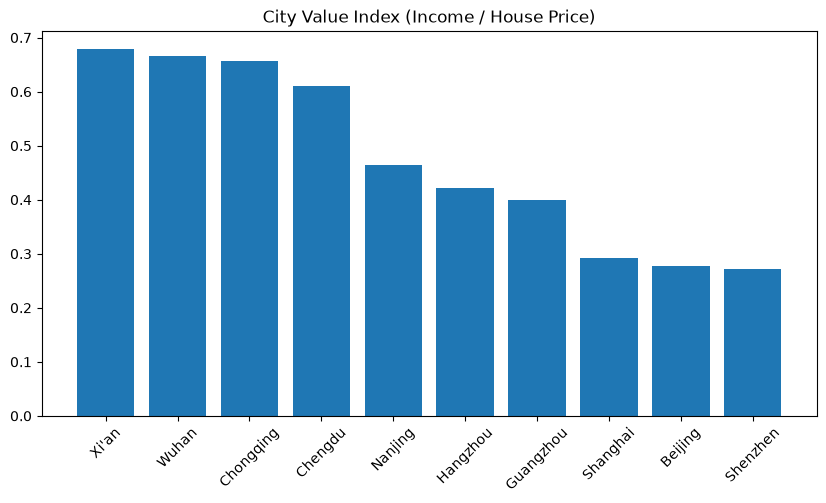

In [23]:
top = df.sort_values("value_index", ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(top["city"], top["value_index"])
plt.title("City Value Index (Income / House Price)")
plt.xticks(rotation=45)
plt.show()

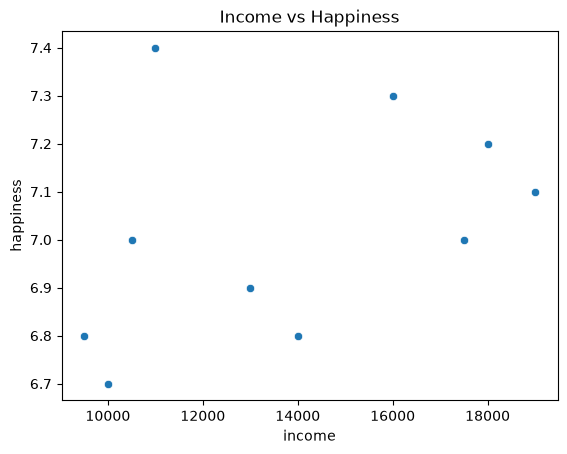

In [24]:
import seaborn as sns

sns.scatterplot(data=df, x="income", y="happiness")
plt.title("Income vs Happiness")
plt.show()

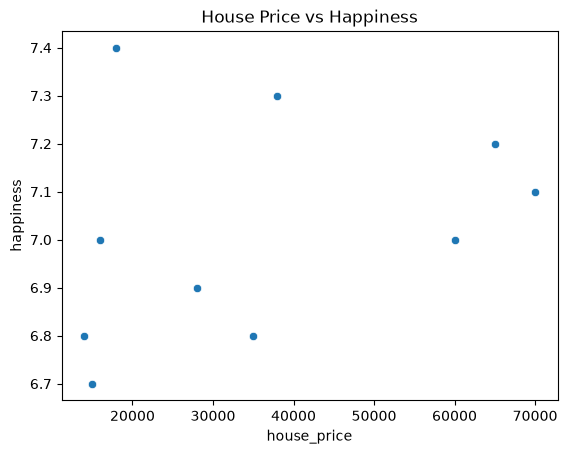

In [25]:
sns.scatterplot(data=df, x="house_price", y="happiness")
plt.title("House Price vs Happiness")
plt.show()

In [30]:
from pyecharts.charts import Map
from pyecharts import options as opts

map_data = list(zip(df["city"], df["happiness"]))

m = Map()
m.add("Happiness", map_data, "china")

m.set_global_opts(
    title_opts=opts.TitleOpts(title="China City Happiness Map"),

    visualmap_opts=opts.VisualMapOpts(
        min_=6.5,
        max_=7.5,
        is_piecewise=True,
        pieces=[
            {"min": 7.3, "label": "Very High"},
            {"min": 7.0, "max": 7.3, "label": "High"},
            {"min": 6.8, "max": 7.0, "label": "Medium"},
            {"max": 6.8, "label": "Low"},
        ]
    ),

    tooltip_opts=opts.TooltipOpts(formatter="{b}: {c}")
)

m.set_series_opts(
    label_opts=opts.LabelOpts(is_show=False)
)

m.render("happiness_map_v3.html")

'C:\\Users\\86132\\Desktop\\中国城市生活成本与幸福感分析可视化\\notebooks\\happiness_map_v3.html'